In [7]:
!pip install torch torchvision tensorflow matplotlib pillow -q

In [8]:
# TensorFlow
import tensorflow as tf
from tensorflow import keras

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

# Common
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [9]:
# TensorFlow dataset
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

print("Train shape:", X_train.shape)

Train shape: (60000, 28, 28)


In [10]:
# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# Reshape for CNN
X_train_tf = X_train.reshape(-1,28,28,1)
X_test_tf = X_test.reshape(-1,28,28,1)

In [11]:
model_tf = keras.Sequential([
    keras.layers.Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    keras.layers.MaxPooling2D((2,2)),

    keras.layers.Conv2D(64,(3,3),activation='relu'),
    keras.layers.MaxPooling2D((2,2)),

    keras.layers.Flatten(),
    keras.layers.Dense(64,activation='relu'),
    keras.layers.Dense(10,activation='softmax')
])

model_tf.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_tf.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
history_tf = model_tf.fit(
    X_train_tf, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.9377 - loss: 0.2037 - val_accuracy: 0.9820 - val_loss: 0.0599
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9812 - loss: 0.0595 - val_accuracy: 0.9863 - val_loss: 0.0481
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9867 - loss: 0.0413 - val_accuracy: 0.9895 - val_loss: 0.0392
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9899 - loss: 0.0315 - val_accuracy: 0.9902 - val_loss: 0.0363
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9921 - loss: 0.0248 - val_accuracy: 0.9868 - val_loss: 0.0435


In [13]:
loss, acc = model_tf.evaluate(X_test_tf, y_test)
print("TensorFlow Test Accuracy:", acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9887 - loss: 0.0354
TensorFlow Test Accuracy: 0.9886999726295471


In [14]:
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = torchvision.datasets.MNIST(
    root='./data', train=True, download=True, transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root='./data', train=False, download=True, transform=transform
)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 493kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.68MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.2MB/s]


In [15]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1,32,3)
        self.conv2 = nn.Conv2d(32,64,3)
        self.pool = nn.MaxPool2d(2,2)

        self.fc1 = nn.Linear(64*5*5,64)
        self.fc2 = nn.Linear(64,10)

    def forward(self,x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(-1,64*5*5)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model_pt = CNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_pt.parameters(), lr=0.001)

In [16]:
for epoch in range(5):
    for images, labels in train_loader:
        outputs = model_pt(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1} done")

Epoch 1 done
Epoch 2 done
Epoch 3 done
Epoch 4 done
Epoch 5 done


In [17]:
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model_pt(images)
        _, predicted = torch.max(outputs.data,1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print("PyTorch Test Accuracy:", correct/total)

PyTorch Test Accuracy: 0.9909


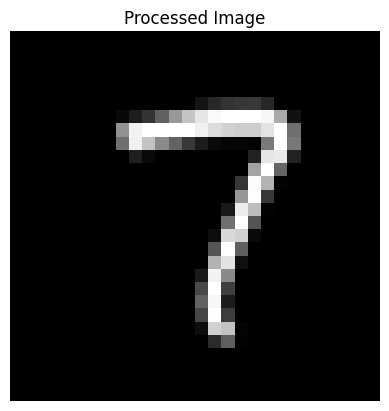

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
TensorFlow Prediction: 7
PyTorch Prediction: 7


In [24]:
from PIL import Image, ImageOps
import numpy as np
import matplotlib.pyplot as plt
import torch

img_path = "test.jpg"

img = Image.open(img_path).convert('L')
img = ImageOps.invert(img)
img = img.resize((28,28))
img_array = np.array(img)

img_array = img_array / 255.0

plt.imshow(img_array, cmap='gray')
plt.title("Processed Image")
plt.axis('off')
plt.show()

img_tf = img_array.reshape(1,28,28,1)
pred_tf = model_tf.predict(img_tf)
print("TensorFlow Prediction:", np.argmax(pred_tf))

img_pt = torch.tensor(img_array).float().unsqueeze(0).unsqueeze(0)
output = model_pt(img_pt)
_, pred_pt = torch.max(output,1)
print("PyTorch Prediction:", pred_pt.item())